In [2]:
import os, sys, pathlib, importlib
import pandas as pd
import json
import time
from tqdm import tqdm
sys.path.append(os.path.abspath(".."))
from utils import preprocess_images
from utils.preprocess_images import download_images_batch

## check

43056 23789
18682


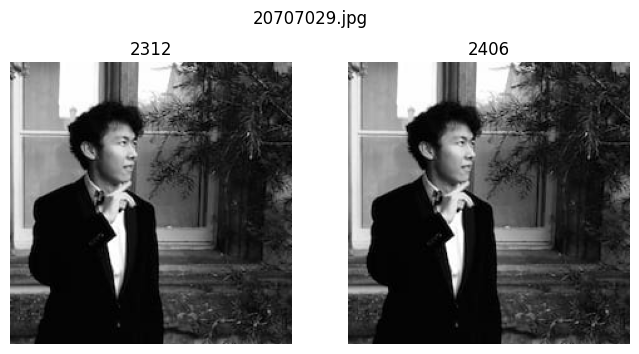

In [34]:
## check duplicates:
import matplotlib.pyplot as plt

folder1='images\paris_2406'
folder2='images\paris_2312'
paris2312=os.listdir(folder1)
paris2406=os.listdir(folder2)

print(len(paris2312), len(paris2406))
comm=list(set(paris2312).intersection(set(paris2406)))
print(len(comm))


## vis

import matplotlib.pyplot as plt
import os


f=comm[10]
img1 = plt.imread(os.path.join(folder1, f))
img2 = plt.imread(os.path.join(folder2, f))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title('2312')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title('2406')
plt.axis('off')

plt.suptitle(f)
plt.show()


## input 2203

In [ ]:
DATA_FOLDER="../data_processed"
IMAGES_FOLDER='images'

os.makedirs(IMAGES_FOLDER, exist_ok=True)

input_output={}
for folder in [ f for f in os.listdir(DATA_FOLDER) if not f.endswith('.csv')]:
    # folder = city+time

    # ---listings---
    files=os.listdir(os.path.join(DATA_FOLDER, folder))
    for f in files:
        if f.startswith('listings_processed'):
            path_listings=os.path.join(DATA_FOLDER, folder, f)
            path_listings_zsc=os.path.join(DATA_FOLDER, folder, f"listings_zsc_{folder}.csv")
    path_results_zsc=os.path.join(DATA_FOLDER, folder, f"resultsZSC_{folder}.csv")

    # ---images folder---
    pic_folder=os.path.join(IMAGES_FOLDER, folder)
    os.makedirs(pic_folder, exist_ok=True)

    # --resultsface---
    resultsFACE_folder=os.path.join(IMAGES_FOLDER, 'results')
    os.makedirs(resultsFACE_folder, exist_ok=True)

    path_results_face=os.path.join(resultsFACE_folder, f"face_{folder}.json")
    path_results_deepface=os.path.join(resultsFACE_folder, f"deepface_{folder}.json")

    # ---gather---
    input_output[folder]={"listings":path_listings,
              "results_zsc":path_results_zsc,
              "listings_zsc":path_listings_zsc,

              'pic_folder':pic_folder,
              'results_face':path_results_face,
              "results_deepface":path_results_deepface}

for k,v in input_output.items():
    print(f"{k}".center(100,'-'))
    path_listings=v['listings']
    path_results_zsc=v['results_zsc']
    path_listings_zsc=v['listings_zsc']

    pic_folder=v['pic_folder']
    path_results_face=v['results_face']
    path_results_deepface=v['results_deepface']
    print(path_listings)
    print(path_results_zsc)
    print(path_listings_zsc,"\n")
    print("pic folder:",pic_folder)
    print(path_results_face)
    print(path_results_deepface,"\n")

--------------------------------------------london_2306---------------------------------------------
../data_processed\london_2306\listings_processed_london_2306_42356.csv
../data_processed\london_2306\resultsZSC_london_2306.csv
../data_processed\london_2306\listings_zsc_london_2306.csv 

images\london_2306
images\results\resultsFACE_london_2306.json 

--------------------------------------------london_2406---------------------------------------------
../data_processed\london_2406\listings_processed_london_2406_49856.csv
../data_processed\london_2406\resultsZSC_london_2406.csv
../data_processed\london_2406\listings_zsc_london_2406.csv 

images\london_2406
images\results\resultsFACE_london_2406.json 

---------------------------------------------paris_2306---------------------------------------------
../data_processed\paris_2306\listings_processed_paris_2306_32901.csv
../data_processed\paris_2306\resultsZSC_paris_2306.csv
../data_processed\paris_2306\listings_zsc_paris_2306.csv 

images

## download pics

In [ ]:
importlib.reload(download_pic)
from utils.download_pic import download_images_batch
download_images_batch(df[:10], out_dir='images/paris_2306', max_workers=12)

[check] dropna + drop_duplicates:10 => 10!
[info] 10/10 downloaded; 0 /10 to download!




[DONE] 0 pics downloaded : 0.00 sec!

success: 0 pics; fails: 0 pics!


{}

## download host pic london

In [ ]:
# df_pic_london_sample=df_pic_london[:10]
id_url_list=[(row['host_id'], row["host_picture_url"]) for _, row in df_pic_london.iterrows()]
print(len(id_url_list))
print(id_url_list[0])


25051
(517837625, 'https://a0.muscache.com/im/pictures/user/d4354a96-266f-4734-b69b-3b66e1de09fa.jpg?aki_policy=profile_x_medium')


In [ ]:
importlib.reload(preprocess_images)
from utils.preprocess_images import download_images_batch
download_images_batch(df_pic_london, out_dir='images/host_pic_london_25051', max_workers=12)


len df:25051!


[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/a53dbc41-91f2-4353-9421-75640dbf0f9a.jpg?aki_policy=profile_x_medium


[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/User-558720586/original/6055dfd9-0d3c-4767-845d-0139ae1158e2.jpeg?aki_policy=profile_x_medium


[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/9868ef0e-4794-410b-bd23-cb04b908ed4a.jpg?aki_policy=profile_x_medium


[WARNING] 无效 URL: https://a0.muscache.com/im/users/13278656/profile_pic/1395186363/original.jpg?aki_policy=profile_x_medium


...

[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/User-200196351/original/3e322f9b-d939-47b1-bd07-870103d2a710.jpeg?aki_policy=profile_x_medium


[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/0297550f-1a3f-4d67-a4af-f70c9a87fc9f.jpg?aki_policy=profile_x_medium



[SUCCES] downloaded 25051 pics : 5551.15 sec!

success: 24819 pics!
fails: 232 pics!


{456550337: 'images/host_pic_london_25051\\456550337.jpg',
 483861278: 'images/host_pic_london_25051\\483861278.jpg',
 102091934: 'images/host_pic_london_25051\\102091934.jpg',
 517837625: 'images/host_pic_london_25051\\517837625.jpg',
 30949469: 'images/host_pic_london_25051\\30949469.jpg',
 487206988: 'images/host_pic_london_25051\\487206988.jpg',
 28880140: 'images/host_pic_london_25051\\28880140.jpg',
 551207872: 'images/host_pic_london_25051\\551207872.jpg',
 483663228: 'images/host_pic_london_25051\\483663228.jpg',
 303622628: 'images/host_pic_london_25051\\303622628.jpg',
 19896713: 'images/host_pic_london_25051\\19896713.jpg',
 403509869: 'images/host_pic_london_25051\\403509869.jpg',
 130940430: 'images/host_pic_london_25051\\130940430.jpg',
 175222658: 'images/host_pic_london_25051\\175222658.jpg',
 252303991: 'images/host_pic_london_25051\\252303991.jpg',
 2902129: 'images/host_pic_london_25051\\2902129.jpg',
 495977998: 'images/host_pic_london_25051\\495977998.jpg',
 448994

: 

## df paris 2312 

In [ ]:
import pandas as pd
path_df="../data_processed_paris2312\listings_paris2312_bge_scores.csv"
df_paris2312=pd.read_csv(path_df)
print(df_paris2312.shape)

df_pic_paris2312=df_paris2312.dropna(subset='host_picture_url').drop_duplicates(subset='host_picture_url')
print(df_pic_paris2312.shape)


(35829, 115)
(23933, 115)


In [ ]:
importlib.reload(preprocess_images)
from utils.preprocess_images import download_images_batch
download_images_batch(df_pic_paris2312, out_dir='images/host_pic_paris2312_23933', max_workers=12)

len df:23933!
[info]21829 pic already saved in images/host_pic_paris2312_23933
2104 pic to save...



[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/97c6bdfe-2a50-4045-845a-7781f5017b09.jpg?aki_policy=profile_x_medium
[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/User-42365573/original/90d9045f-f159-45ea-a79d-8c2465e8b7ba.jpeg?aki_policy=profile_x_medium
[WARNING] 无效 URL: https://a0.muscache.com/im/users/13049402/profile_pic/1394618714/original.jpg?aki_policy=profile_x_medium
[WARNING] 无效 URL: https://a0.muscache.com/im/users/5947575/profile_pic/1366192247/original.jpg?aki_policy=profile_x_medium


[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/7cfc7ecb-8992-44c0-ac66-708a53c1a0a7.jpg?aki_policy=profile_x_medium
[WARNING] 无效 URL: https://a0.muscache.com/im/users/37872891/profile_pic/1436369862/original.jpg?aki_policy=profile_x_medium
[WARNING] 无效 URL: https://a0.muscache.com/im/users/295001/profile_pic/1371196555/original.jpg?aki_policy=profile_x_medium
[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/7cfde02b-e807-405c-bb15-d0b3a26d0186.jpg?aki_policy=profile_x_medium
[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/94606f01-2440-48da-bea0-e43c6ff72983.jpg?aki_policy=profile_x_medium
[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/4d5097fb-cde3-449f-939f-7804c7c94fc6.jpg?aki_policy=profile_x_medium
[WARNING] 无效 URL: https://a0.muscache.com/im/users/8994534/profile_pic/1420292008/original.jpg?aki_policy=profile_x_medium
[WARNING] 无效 URL: https://a0.muscache.com/im/users/12348545/profile_pic/1399889078/original.jpg?aki_policy=profile_x_me

[WARNING] 无效 URL: https://a0.muscache.com/im/users/11250660/profile_pic/1392220006/original.jpg?aki_policy=profile_x_medium


[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/User-68634366/original/051abad3-ccf0-46ca-a54f-cc7643bba373.jpeg?aki_policy=profile_x_medium
[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/b9eabe7e-7fef-44c5-abe3-4b980c7848ea.jpg?aki_policy=profile_x_medium


...

[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/94261786-3d80-4d8e-ac6f-39b215a00267.jpg?aki_policy=profile_x_medium


[WARNING] 无效 URL: https://a0.muscache.com/im/users/43493910/profile_pic/1441547988/original.jpg?aki_policy=profile_x_medium


[WARNING] 无效 URL: https://a0.muscache.com/im/pictures/user/User-206606743/original/6a5c3a96-1bb7-4297-b683-def6dc1c21df.jpeg?aki_policy=profile_x_medium



[SUCCES] downloaded 23933 pics : 584.98 sec!

success: 1960 pics!
fails: 144 pics!


{'54855676': None,
 '42365573': None,
 '13049402': None,
 '5947575': None,
 '1586572': None,
 '37872891': None,
 '295001': None,
 '10598872': None,
 '1008345': None,
 '14929981': None,
 '8994534': None,
 '12348545': None,
 '17038131': None,
 '11250660': None,
 '68634366': None,
 '96148496': None,
 '17987961': None,
 '132422409': None,
 '141967787': None,
 '10893554': None,
 '26946246': 'images/host_pic_paris2312_23933\\26946246.jpg',
 '75908560': None,
 '114291302': None,
 '101596702': 'images/host_pic_paris2312_23933\\101596702.jpg',
 '89314181': None,
 '7233751': 'images/host_pic_paris2312_23933\\7233751.jpg',
 '77054830': None,
 '60987750': None,
 '118457368': None,
 '91950575': None,
 '139616202': None,
 '237408284': None,
 '50366446': None,
 '41664365': None,
 '148971716': None,
 '10725710': None,
 '21322244': None,
 '114407': None,
 '48970944': 'images/host_pic_paris2312_23933\\48970944.jpg',
 '14010395': None,
 '262014994': None,
 '12781315': None,
 '37834204': None,
 '44484854'